In [116]:
# @title 물성라이브러리 설치 code
!pip install cantera
!pip install CoolProp
import cantera as ct
print(ct.__version__)

3.2.0


In [173]:
# @title 조건 입력 code
params = {

    "v_lng_tank_m3_per_hr": 550.0, # LNG 체적 유량 (m3/h) - 입력
    "v_bog_tank_m3_per_hr": 18100.0, # BOG 체적 유량 (m3/h) - 입력

    # 총 BOG 유량, BOG 압축기 후 분할 (이제는 체적 유량으로부터 계산됩니다.)
    # "m_bog_total": 35.0,

    # LNG 저장 탱크 및 실제 펌프 입구 조건
    "T_lng_tank": C_to_K(-162.0),
    "P_lng_tank": bar_to_Pa(5.0),

    # LNG 2차 펌프 출구는 펌핑 후 가열된다고 가정합니다.
    # 이것은 LNG 스트림의 디슈퍼히터 이전의 목표 온도입니다.
    "T_lng_pump_out_heated": C_to_K(-130.0),

    # LNG 2차 펌프 출구 압력
    "P_lng_high": bar_to_Pa(80.0),

    "T_bog_tank": C_to_K(-100.0),
    "P_bog_tank": bar_to_Pa(1.157),
    "P_bog_comp_out": bar_to_Pa(9.91), # 단일 BOG 압축기의 목표 출구 압력

    # 다음 매개변수들은 더 이상 사용되지 않습니다.
    # "P_bog_hpc_out": bar_to_Pa(8.0),
    # "T_sendout": C_to_K(15.0),
    # "P_sendout": bar_to_Pa(70.0),

    "pump_eta": 0.75,
    "comp_eta": 0.665,
    "desuperheater_effectiveness": 0.70 # 디슈퍼히터 효율에 대한 새로운 매개변수
}

In [174]:
# @title Procsess modeling code
import os
import pandas as pd
from CoolProp.CoolProp import PropsSI

methane_mass_fraction = 0.95 # BOG용: 메탄 79%
nitrogen_mass_fraction = 0.05 # BOG용: 질소 21%
FLUID = f"Methane[{methane_mass_fraction}]&Nitrogen[{nitrogen_mass_fraction}]" # BOG용 유체

methane_mass_fraction_lng = 1.0 # LNG용: 메탄 100%
nitrogen_mass_fraction_lng = 0.0 # LNG용: 질소 0%
FLUID_LNG = f"Methane[{methane_mass_fraction_lng}]&Nitrogen[{nitrogen_mass_fraction_lng}]" # LNG용 유체

def C_to_K(T_C):
    # 섭씨 온도를 켈빈 온도로 변환
    return T_C + 273.15

def K_to_C(T_K):
    # 켈빈 온도를 섭씨 온도로 변환
    return T_K - 273.15

def bar_to_Pa(P_bar):
    # bar 단위를 파스칼(Pa)로 변환
    return P_bar * 1e5

def Pa_to_bar(P_Pa):
    # 파스칼(Pa) 단위를 bar로 변환
    return P_Pa / 1e5

# =====================================================
# 1. CoolProp 속성 도우미 함수들
# =====================================================

def h_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔탈피(Hmass) 계산
    try:
        return PropsSI("Hmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Hmass", "T", T + 0.1, "P", P, fluid)

def s_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔트로피(Smass) 계산
    try:
        return PropsSI("Smass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Smass", "T", T + 0.1, "P", P, fluid)

def T_Ph(P, h, fluid):
    # 압력(P)과 질량 엔탈피(h)로 온도(T) 계산
    return PropsSI("T", "P", P, "Hmass", h, fluid)

def h_PS(P, s, fluid):
    # 압력(P)과 질량 엔트로피(s)로 질량 엔탈피(Hmass) 계산 (등엔트로피 과정)
    return PropsSI("Hmass", "P", P, "Smass", s, fluid)

def rho_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 밀도(Dmass) 계산
    try:
        return PropsSI("Dmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Dmass", "T", T + 0.1, "P", P, fluid)

# =====================================================
# 2. 컴포넌트 모델
# =====================================================

def liquid_pump(m_dot, T_in, P_in, P_out, eta=0.75, fluid=FLUID_LNG):
    # 액체 펌프 모델
    h_in = h_TP(T_in, P_in, fluid)
    rho = rho_TP(T_in, P_in, fluid)

    if rho < 100.0:
        # 펌프 입구 밀도가 너무 낮으면 오류 발생 (액체가 아닌 증기/이상 상태일 가능성)
        raise ValueError(
            f"액체 펌프 입구 밀도가 너무 낮습니다 ({rho:.3f} kg/m3). "
            "입구는 증기/이상 상태일 가능성이 높습니다. "
            "펌프 입구 압력을 높이거나 펌프 입구 온도를 낮추십시오."
        )

    # 펌프 일 (엔탈피 변화)
    dh = (P_out - P_in) / rho / eta
    h_out = h_in + dh
    T_out = T_Ph(P_out, h_out, fluid)
    W = m_dot * dh

    return {
        "T_out": T_out, # 출구 온도
        "P_out": P_out, # 출구 압력
        "h_out": h_out, # 출구 엔탈피
        "W": W,         # 펌프 동력
        "rho_in": rho,  # 입구 밀도
    }

def compressor(m_dot, T_in, P_in, P_out, eta=0.75, fluid=FLUID):
    # 압축기 모델
    if m_dot <= 0:
        # 질량 유량이 없으면 압축기 동력은 0
        return {
            "T_out": T_in,
            "P_out": P_out,
            "h_out": h_TP(T_in, P_out, fluid),
            "W": 0.0,
        }

    h_in = h_TP(T_in, P_in, fluid)
    s_in = s_TP(T_in, P_in, fluid)
    # 등엔트로피 출구 엔탈피
    h_out_s = h_PS(P_out, s_in, fluid)
    # 실제 출구 엔탈피 (효율 반영)
    h_out = h_in + (h_out_s - h_in) / eta
    T_out = T_Ph(P_out, h_out, fluid)
    # 압축기 동력
    W = m_dot * (h_out - h_in)

    return {
        "T_out": T_out,
        "P_out": P_out,
        "h_out": h_out,
        "W": W,
    }

def heat_exchanger_effectiveness(
    m_cold,
    T_cold_in,
    P_cold,
    fluid_cold,
    m_hot,
    T_hot_in,
    P_hot,
    fluid_hot,
    effectiveness=0.60,
    min_delta_T=3.0,
):
    """
    일반적인 열교환기 유용도(effectiveness) 모델.
    뜨거운 스트림이 차가운 스트림에 열을 전달합니다.
    """
    if m_hot <= 0 or effectiveness <= 0:
        # 뜨거운 유량 또는 유용도가 0 이하면 열 전달 없음
        return {
            "Q": 0.0,
            "T_cold_out": T_cold_in,
            "h_cold_out": h_TP(T_cold_in, P_cold, fluid_cold),
            "T_hot_out": T_hot_in,
            "h_hot_out": h_TP(T_hot_in, P_hot, fluid_hot),
        }

    h_hot_in = h_TP(T_hot_in, P_hot, fluid_hot)
    h_cold_in = h_TP(T_cold_in, P_cold, fluid_cold)
    # 최소 접근 온도 차이를 고려한 뜨거운 스트림의 최소 온도
    T_hot_min = T_cold_in + min_delta_T
    h_hot_min = h_TP(T_hot_min, P_hot, fluid_hot)

    # 최대 가능한 열량 (뜨거운 스트림 기준)
    Q_max_hot = m_hot * max(h_hot_in - h_hot_min, 0.0)
    # 실제 열 전달량 (유용도 반영)
    Q = effectiveness * Q_max_hot

    # 출구 엔탈피 계산
    h_hot_out = h_hot_in - Q / m_hot
    h_cold_out = h_cold_in + Q / m_cold

    # 출구 온도 계산
    T_hot_out = T_Ph(P_hot, h_hot_out, fluid_hot)
    T_cold_out = T_Ph(P_cold, h_cold_out, fluid_cold)

    return {
        "Q": Q,                             # 열 전달량
        "T_cold_out": T_cold_out,         # 차가운 스트림 출구 온도
        "h_cold_out": h_cold_out,         # 차가운 스트림 출구 엔탈피
        "T_hot_out": T_hot_out,           # 뜨거운 스트림 출구 온도
        "h_hot_out": h_hot_out,           # 뜨거운 스트림 출구 엔탈피
    }

def set_stream_temperature(m_dot, T_in, P, T_target, fluid):
    """
    히터/쿨러를 적용하여 동일 압력에서 스트림 온도를 설정합니다.
    양의 Q는 스트림에 열이 추가됨을 의미합니다.
    """
    h_in = h_TP(T_in, P, fluid)
    h_out = h_TP(T_target, P, fluid)
    # 필요한 열량
    Q = m_dot * (h_out - h_in)

    return {
        "Q": Q,
        "T_out": T_target,
        "P_out": P,
        "h_out": h_out,
    }


# =====================================================
# 3. 다단 HPC 모델 (사용하지 않음)
# =====================================================

def get_hpc_stage_pressures(P_in, P_out, n_stages):
    """
    균등 압력비 단계.
    경계 압력: [P0, P1, ..., Pn]을 반환합니다.
    """
    pr_stage = (P_out / P_in) ** (1.0 / n_stages)
    pressures = [P_in]
    for _ in range(n_stages):
        pressures.append(pressures[-1] * pr_stage)
    pressures[-1] = P_out # 마지막 압력을 P_out으로 강제 설정하여 부동 소수점 오차 방지
    return pressures


def multistage_hpc_no_intercooling(m_dot, T_in, P_in, P_out, eta=0.75, n_stages=3, fluid=FLUID):
    # 중간 냉각 없는 다단 고압 압축기(HPC) 모델
    # 이 함수는 현재 간소화된 모델에서 사용되지 않습니다.
    pressures = get_hpc_stage_pressures(P_in, P_out, n_stages)
    T = T_in
    W_total = 0.0
    stage_results = []

    for i in range(n_stages):
        T_stage_in = T
        comp = compressor(m_dot, T_stage_in, pressures[i], pressures[i + 1], eta, fluid=fluid)
        W_total += comp["W"]
        T = comp["T_out"]

        stage_results.append({
            "stage": i + 1,
            "P_in": pressures[i],
            "P_out": pressures[i + 1],
            "T_in": T_stage_in,
            "T_out": comp["T_out"],
            "W": comp["W"],
        })

    return {
        "T_out": T,
        "P_out": P_out,
        "W": W_total,
        "stages": stage_results,
    }


# =====================================================
# 4. 전체 공정 모델 헬퍼 함수
# =====================================================

def _assemble_simplified_results(
    params,
    m_lng,
    m_bog_total,
    vol_lng_m3_per_hr,
    rho_lng_tank,
    vol_bog_m3_per_hr,
    rho_bog_tank,
    pump_results,
    Q_lng_pump_out_heating,
    T_lng_after_pump_calc,
    P_lng_after_pump,
    T_lng_after_desuperheater,
    T_bog_after_desuperheater,
    Q_desuperheater,
    comp_bog_results,
    T_bog_comp_out,
    P_bog_comp_out
):

    # 총 전력 및 열량 계산
    total_power_mw = (pump_results["W"] + comp_bog_results["W"]) / 1e6
    pump_out_heating_duty_mw = Q_lng_pump_out_heating / 1e6
    desuperheater_duty_mw = Q_desuperheater / 1e6

    return {
        "LNG_TANK_VOL_FLOW_M3_PER_HR": vol_lng_m3_per_hr, # LNG 탱크 체적 유량 (입력)
        "LNG_TANK_RHO_KG_PER_M3": rho_lng_tank, # LNG 탱크 밀도 (계산)
        "LNG_MASS_FLOW_KG_PER_S": m_lng, # LNG 질량 유량 (계산)

        "BOG_TANK_VOL_FLOW_M3_PER_HR": vol_bog_m3_per_hr, # BOG 탱크 체적 유량 (입력)
        "BOG_TANK_RHO_KG_PER_M3": rho_bog_tank, # BOG 탱크 밀도 (계산)
        "BOG_TOTAL_MASS_FLOW_KG_PER_S": m_bog_total, # BOG 질량 유량 (계산)

        "LNG_TANK_T_C": K_to_C(params["T_lng_tank"]), # LNG 탱크 온도 (섭씨)
        "LNG_TANK_P_BAR": Pa_to_bar(params["P_lng_tank"]), # LNG 탱크 압력 (bar)
        "LNG_PUMP_OUT_CALC_T_C": K_to_C(T_lng_after_pump_calc), # LNG 펌프 출구 계산된 온도 (섭씨)
        "LNG_PUMP_OUT_P_BAR": Pa_to_bar(P_lng_after_pump), # LNG 펌프 출구 압력 (bar)
        "LNG_PUMP_OUT_HEATED_T_C": K_to_C(T_lng_after_desuperheater), # LNG 디슈퍼히터 출구 온도 (섭씨)
        "LNG_PUMP_OUT_HEATING_DUTY_MW": pump_out_heating_duty_mw, # LNG 펌프 출구 가열 열량 (MW)

        "BOG_TANK_T_C": K_to_C(params["T_bog_tank"]),     # BOG 탱크 온도 (섭씨)
        "BOG_TANK_P_BAR": Pa_to_bar(params["P_bog_tank"]), # BOG 탱크 압력 (bar)
        "BOG_DESUPERHEATER_OUT_T_C": K_to_C(T_bog_after_desuperheater), # BOG 디슈퍼히터 출구 온도 (섭씨)
        "BOG_COMP_OUT_T_C": K_to_C(T_bog_comp_out),       # BOG 압축기 출구 온도 (섭씨)
        "BOG_COMP_OUT_P_BAR": Pa_to_bar(P_bog_comp_out), # BOG 압축기 출구 압력 (bar)
        "BOG_FINAL_SENDOUT_MASS_FLOW": m_bog_total, # BOG 최종 송출 질량 유량 (압축기 출구) (계산)

        "DESUPERHEATER_DUTY_MW": desuperheater_duty_mw,    # 디슈퍼히터 열량 (MW)
        "LNG_PUMP_POWER_MW": pump_results["W"] / 1e6,              # LNG 펌프 동력 (MW)
        "BOG_COMP_POWER_MW": comp_bog_results["W"] / 1e6,          # BOG 압축기 동력 (MW)
        "TOTAL_POWER_MW": total_power_mw,                  # 총 동력 (MW)
    }

def simulate_process(params):
    # 주요 매개변수 추출
    v_lng_tank_m3_per_hr = params["v_lng_tank_m3_per_hr"]
    v_bog_tank_m3_per_hr = params["v_bog_tank_m3_per_hr"]

    # 명확성을 위한 주요 매개변수 추출
    P_lng_tank = params["P_lng_tank"]
    T_lng_tank = params["T_lng_tank"]
    P_lng_high = params["P_lng_high"]
    T_lng_pump_out_initial = params["T_lng_pump_out_heated"]

    P_bog_tank = params["P_bog_tank"]
    T_bog_tank = params["T_bog_tank"]
    P_bog_comp_out_target = params["P_bog_comp_out"]

    # LNG 탱크 밀도 계산 및 질량 유량 변환
    rho_lng_tank = rho_TP(T_lng_tank, P_lng_tank, FLUID_LNG)
    m_lng = v_lng_tank_m3_per_hr * rho_lng_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s

    # BOG 탱크 밀도 계산 및 질량 유량 변환
    rho_bog_tank = rho_TP(T_bog_tank, P_bog_tank, FLUID)
    m_bog_total = v_bog_tank_m3_per_hr * rho_bog_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s


    # 1. LNG 펌프
    pump = liquid_pump(
        m_dot=m_lng,
        T_in=T_lng_tank,
        P_in=P_lng_tank,
        P_out=P_lng_high,
        eta=params["pump_eta"],
        fluid=FLUID_LNG
    )

    T_lng_after_pump_calc = pump["T_out"]
    P_lng_after_pump = pump["P_out"]

    # 펌프 출구 초기 가열 (디슈퍼히터 이전)
    pump_out_heater = set_stream_temperature(
        m_dot=m_lng,
        T_in=T_lng_after_pump_calc,
        P=P_lng_after_pump,
        T_target=T_lng_pump_out_initial,
        fluid=FLUID_LNG
    )
    T_lng_initial_heated = pump_out_heater["T_out"]
    Q_lng_pump_out_heating = pump_out_heater["Q"]

    # 2. 디슈퍼히터 (LNG cold side, BOG hot side)
    # BOG는 탱크에서 바로 디슈퍼히터로 들어갑니다.
    desuperheater_results = heat_exchanger_effectiveness(
        m_cold=m_lng,
        T_cold_in=T_lng_initial_heated,
        P_cold=P_lng_after_pump,
        fluid_cold=FLUID_LNG,
        m_hot=m_bog_total,
        T_hot_in=T_bog_tank, # BOG는 탱크에서 직접 들어옴
        P_hot=P_bog_tank, # BOG는 탱크 압력으로 들어옴
        fluid_hot=FLUID,
        effectiveness=params["desuperheater_effectiveness"]
    )

    T_lng_after_desuperheater = desuperheater_results["T_cold_out"]
    T_bog_after_desuperheater = desuperheater_results["T_hot_out"]
    Q_desuperheater = desuperheater_results["Q"]

    # 3. BOG 저압 압축기 (디슈퍼히터 이후, 유일한 BOG 압축기)
    # BOG 공정은 여기서 검토 종료
    comp_bog_results = compressor(
        m_dot=m_bog_total,
        T_in=T_bog_after_desuperheater, # 디슈퍼히터 출구 온도가 압축기 입구 온도
        P_in=P_bog_tank, # 디슈퍼히터에서 압력 강하는 없다고 가정, 탱크 압력으로 압축기 입구
        P_out=P_bog_comp_out_target, # 목표 압축기 출구 압력
        eta=params["comp_eta"],
        fluid=FLUID
    )
    T_bog_comp_out = comp_bog_results["T_out"]
    P_bog_comp_out = comp_bog_results["P_out"]


    # 4. 결과 취합
    return _assemble_simplified_results(
        params=params,
        m_lng=m_lng,
        m_bog_total=m_bog_total,
        vol_lng_m3_per_hr=v_lng_tank_m3_per_hr,
        rho_lng_tank=rho_lng_tank,
        vol_bog_m3_per_hr=v_bog_tank_m3_per_hr,
        rho_bog_tank=rho_bog_tank,
        pump_results=pump,
        Q_lng_pump_out_heating=Q_lng_pump_out_heating,
        T_lng_after_pump_calc=T_lng_after_pump_calc,
        P_lng_after_pump=P_lng_after_pump,
        T_lng_after_desuperheater=T_lng_after_desuperheater,
        T_bog_after_desuperheater=T_bog_after_desuperheater,
        Q_desuperheater=Q_desuperheater,
        comp_bog_results=comp_bog_results,
        T_bog_comp_out=T_bog_comp_out,
        P_bog_comp_out=P_bog_comp_out
    )


In [175]:
# @title 위상 판단 code
import pandas as pd
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI

def get_phase_string(T_C, P_bar, fluid):
    T_K = C_to_K(T_C)
    P_Pa = bar_to_Pa(P_bar)

    try:
        # Get critical properties for the fluid
        Tc_K = CP.PropsSI('Tcrit', fluid)
        Pc_Pa = CP.PropsSI('Pcrit', fluid)

        # 1. Check for True Supercritical Region
        if T_K >= Tc_K and P_Pa >= Pc_Pa:
            return '초임계'

        # 2. Handle subcritical regions using saturation properties
        try:
            # Get saturation temperature at the given pressure
            # If pressure is above critical pressure, T_sat cannot be found, which is caught by ValueError
            T_sat_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 0, fluid) # Saturated liquid temperature

            if T_K > T_sat_K:
                # If temperature is above saturation temperature, it's a gas (superheated vapor)
                try:
                    # Try to get Q to distinguish saturated vapor (Q=1) from superheated vapor (Q>1, or CoolProp's '2')
                    Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                    if Q > 0 and Q < 1: # Should not happen here if T > T_sat, but as a safeguard
                        return f'기액 이중상 (건도: {Q:.2f})'
                    elif Q >= 1: # Superheated or saturated vapor
                        return '기체'
                    else: # Fallback for odd Q values (e.g., Q=-1 for gas, sometimes happens far from dome)
                        return '기체'
                except ValueError: # Q calculation might fail for superheated vapor far from dome
                    return '기체'
            elif T_K < T_sat_K:
                # If temperature is below saturation temperature, it's a liquid (subcooled liquid)
                try:
                    # Try to get Q to distinguish saturated liquid (Q=0) from subcooled liquid (Q<0, or CoolProp's '-1')
                    Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                    if Q > 0 and Q < 1: # Should not happen here if T < T_sat, but as a safeguard
                        return f'기액 이중상 (건도: {Q:.2f})'
                    elif Q <= 0: # Subcooled or saturated liquid
                        return '액체'
                    else: # Fallback for odd Q values (e.g., Q=2 for liquid, sometimes happens far from dome)
                        return '액체'
                except ValueError: # Q calculation might fail for subcooled liquid far from dome
                    return '액체'
            else: # T_K == T_sat_K, it's a saturated state
                try:
                    Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                    if Q > 0 and Q < 1:
                        return f'기액 이중상 (건도: {Q:.2f})'
                    elif Q == 0: return '포화 액체'
                    elif Q == 1: return '포화 기체'
                    else: return '포화상태 (정확한 위상 확인 필요)'
                except ValueError:
                    return '포화상태 (정확한 위상 확인 불가)'

        except ValueError:
            # T_sat_K calculation failed. This often happens if the state is truly supercritical,
            # or if the pressure is above the critical pressure, but temperature is below critical temperature (compressed liquid),
            # or if the pressure is below critical pressure, but temperature is above critical temperature (superheated gas).
            # The supercritical check (T >= Tc and P >= Pc) handled the first case.
            # Now, handle the other "pseudo-supercritical" or highly superheated/compressed regions.

            if T_K >= Tc_K and P_Pa < Pc_Pa: # T > Tc, P < Pc (Superheated gas - could also be considered 'supercritical gas phase' by CoolProp)
                return '기체'
            elif T_K < Tc_K and P_Pa >= Pc_Pa: # T < Tc, P > Pc (Compressed liquid - could also be considered 'supercritical liquid phase' by CoolProp)
                return '액체'
            else:
                # Fallback to CoolProp's raw alphanumeric phase string if other methods fail
                raw_phase_output_str = CP.PropsSI('Phase_ALPHANUMERIC', 'T', T_K, 'P', P_Pa, fluid)
                if raw_phase_output_str in ['liquid', 'SupercriticalLiquid_Phase', 'Subcritical_Liquid']: return '액체'
                elif raw_phase_output_str in ['gas', 'SupercriticalGas_Phase', 'Subcritical_Gas']: return '기체'
                elif raw_phase_output_str == 'critical_point': return '임계점'
                elif raw_phase_output_str == 'supercritical': return '초임계'
                elif raw_phase_output_str == 'two_phase':
                    try:
                        Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                        return f'기액 이중상 (건도: {Q:.2f})'
                    except ValueError:
                        return '기액 이중상 (건도 확인 불가)'
                return f'알 수 없음 ({raw_phase_output_str})'

    except ValueError as e:
        return f'알 수 없음 (CoolProp 오류: {e})'
    except Exception as e:
        return f'오류 발생: {type(e).__name__}'

In [176]:
#@title 결과 테이블
results = simulate_process(params)

data_points = []

# LNG Stream
# LNG 탱크
data_points.append({
    '위치': 'LNG 탱크',
    '온도 [°C]': f"{results['LNG_TANK_T_C']:.2f} (입력)",
    '압력 [bar]': f"{results['LNG_TANK_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{results['LNG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (입력)",
    '밀도 [kg/m³]': f"{results['LNG_TANK_RHO_KG_PER_M3']:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['LNG_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['LNG_TANK_T_C'], results['LNG_TANK_P_BAR'], FLUID_LNG),
    '조성': '메탄 100%, 질소 0%',
    '다음 위치': 'LNG 펌프 출구 (계산)'
})

# LNG 펌프 출구 (계산된 상태)
rho_lng_pump_out_calc = rho_TP(C_to_K(results['LNG_PUMP_OUT_CALC_T_C']), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    '위치': 'LNG 펌프 출구 (계산)',
    '온도 [°C]': f"{results['LNG_PUMP_OUT_CALC_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_pump_out_calc * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_lng_pump_out_calc:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['LNG_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['LNG_PUMP_OUT_CALC_T_C'], results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    '조성': '메탄 100%, 질소 0%',
    '다음 위치': 'LNG 펌프 출구 (초기 가열 목표)'
})

# LNG 펌프 출구 (초기 가열 목표)
rho_lng_pump_out_heated_rho = rho_TP(C_to_K(params["T_lng_pump_out_heated"]), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    '위치': 'LNG 펌프 출구 (초기 가열 목표)',
    '온도 [°C]': f"{K_to_C(params['T_lng_pump_out_heated']):.2f} (입력)",
    '압력 [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_pump_out_heated_rho * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_lng_pump_out_heated_rho:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['LNG_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(K_to_C(params['T_lng_pump_out_heated']), results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    '조성': '메탄 100%, 질소 0%',
    '다음 위치': 'LNG 디슈퍼히터 출구'
})

# LNG 디슈퍼히터 출구
rho_lng_desuperheater_out = rho_TP(C_to_K(results['LNG_PUMP_OUT_HEATED_T_C']), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    '위치': 'LNG 디슈퍼히터 출구',
    '온도 [°C]': f"{results['LNG_PUMP_OUT_HEATED_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (입력)", # 압력 강하 없다고 가정
    '체적 유량 [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_desuperheater_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_lng_desuperheater_out:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['LNG_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['LNG_PUMP_OUT_HEATED_T_C'], results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    '조성': '메탄 100%, 질소 0%',
    '다음 위치': '(LNG 최종 스코프)'
})

# BOG Stream
# BOG 탱크
data_points.append({
    '위치': 'BOG 탱크',
    '온도 [°C]': f"{results['BOG_TANK_T_C']:.2f} (입력)",
    '압력 [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{results['BOG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (입력)",
    '밀도 [kg/m³]': f"{results['BOG_TANK_RHO_KG_PER_M3']:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['BOG_TANK_T_C'], results['BOG_TANK_P_BAR'], FLUID),
    '조성': '메탄 95%, 질소 5%',
    '다음 위치': 'BOG 디슈퍼히터 입구'
})

# BOG 디슈퍼히터 출구
rho_bog_desuperheater_out = rho_TP(C_to_K(results['BOG_DESUPERHEATER_OUT_T_C']), bar_to_Pa(results['BOG_TANK_P_BAR']), FLUID)
data_points.append({
    '위치': 'BOG 디슈퍼히터 출구',
    '온도 [°C]': f"{results['BOG_DESUPERHEATER_OUT_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (입력)", # 압력 강하 없다고 가정
    '체적 유량 [m³/h]': f"{(results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] / rho_bog_desuperheater_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_bog_desuperheater_out:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['BOG_DESUPERHEATER_OUT_T_C'], results['BOG_TANK_P_BAR'], FLUID),
    '조성': '메탄 95%, 질소 5%',
    '다음 위치': 'BOG 저압 압축기 입구'
})

# BOG 저압 압축기 출구
rho_bog_comp_out = rho_TP(C_to_K(results['BOG_COMP_OUT_T_C']), bar_to_Pa(results['BOG_COMP_OUT_P_BAR']), FLUID)
data_points.append({
    '위치': 'BOG 저압 압축기 출구',
    '온도 [°C]': f"{results['BOG_COMP_OUT_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['BOG_COMP_OUT_P_BAR']:.2f} (입력)", # 압력 강하는 없다고 가정
    '체적 유량 [m³/h]': f"{(results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] / rho_bog_comp_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_bog_comp_out:.2f} (계산)",
    '질량 유량 [kg/s]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S']:.2f} (계산)",
    '위상': get_phase_string(results['BOG_COMP_OUT_T_C'], results['BOG_COMP_OUT_P_BAR'], FLUID),
    '조성': '메탄 95%, 질소 5%',
    '다음 위치': '(BOG 최종 스코프)'
})

# 데이터프레임 생성
df_streams_full = pd.DataFrame(data_points)

print("\n=== 스트림 데이터 요약 ===")
display(df_streams_full)



=== 스트림 데이터 요약 ===


,위치,온도 [°C],압력 [bar],체적 유량 [m³/h],밀도 [kg/m³],질량 유량 [kg/s],위상,조성,다음 위치
0,LNG 탱크,-162.00 (입력),5.00 (입력),550.00 (입력),423.49 (계산),64.70 (계산),액체,"메탄 100%, 질소 0%",LNG 펌프 출구 (계산)
1,LNG 펌프 출구 (계산),-158.35 (계산),80.00 (입력),547.92 (계산),425.09 (계산),64.70 (계산),액체,"메탄 100%, 질소 0%",LNG 펌프 출구 (초기 가열 목표)
2,LNG 펌프 출구 (초기 가열 목표),-130.00 (입력),80.00 (입력),6158.26 (계산),37.82 (계산),64.70 (계산),액체,"메탄 100%, 질소 0%",LNG 디슈퍼히터 출구
3,LNG 디슈퍼히터 출구,-128.89 (계산),80.00 (입력),610.13 (계산),381.75 (계산),64.70 (계산),액체,"메탄 100%, 질소 0%",(LNG 최종 스코프)
4,BOG 탱크,-100.00 (입력),1.16 (입력),18100.00 (입력),1.35 (계산),6.80 (계산),기체,"메탄 95%, 질소 5%",BOG 디슈퍼히터 입구
5,BOG 디슈퍼히터 출구,-118.93 (계산),1.16 (입력),16049.75 (계산),1.52 (계산),6.80 (계산),기체,"메탄 95%, 질소 5%",BOG 저압 압축기 입구
6,BOG 저압 압축기 출구,41.86 (계산),9.91 (입력),3835.96 (계산),6.38 (계산),6.80 (계산),기체,"메탄 95%, 질소 5%",(BOG 최종 스코프)


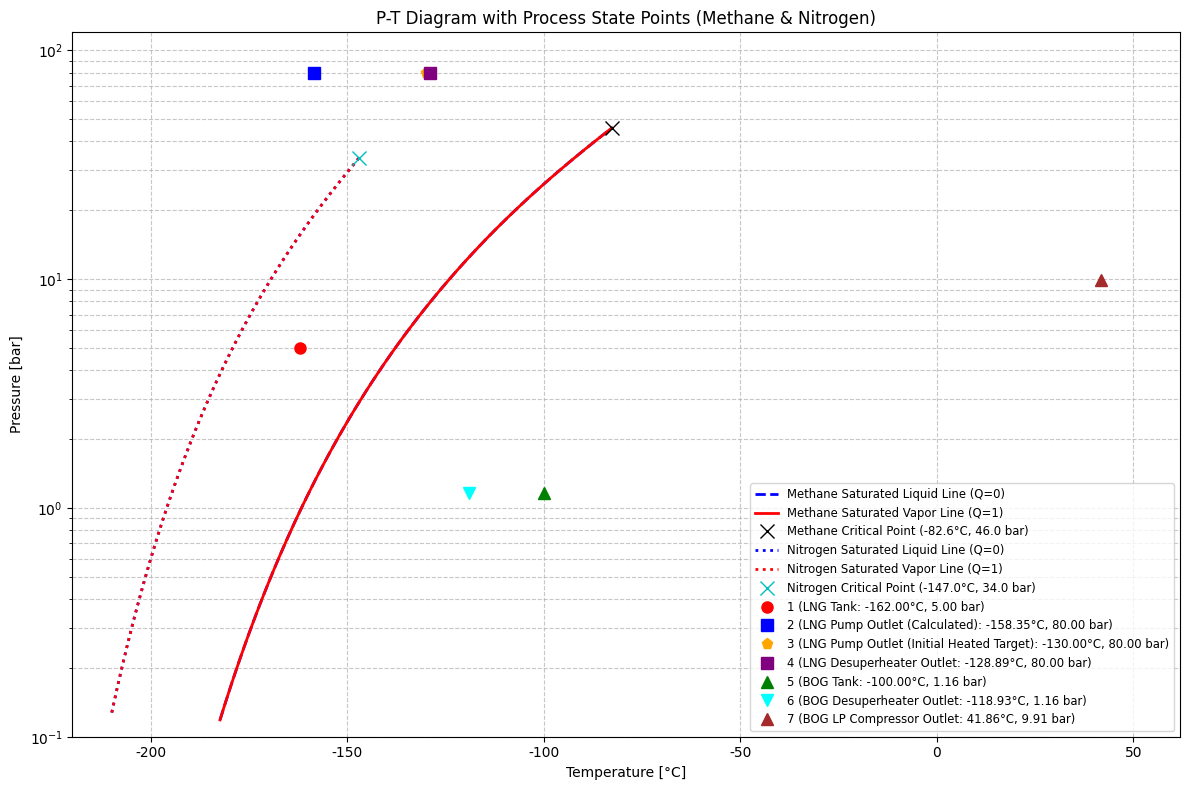

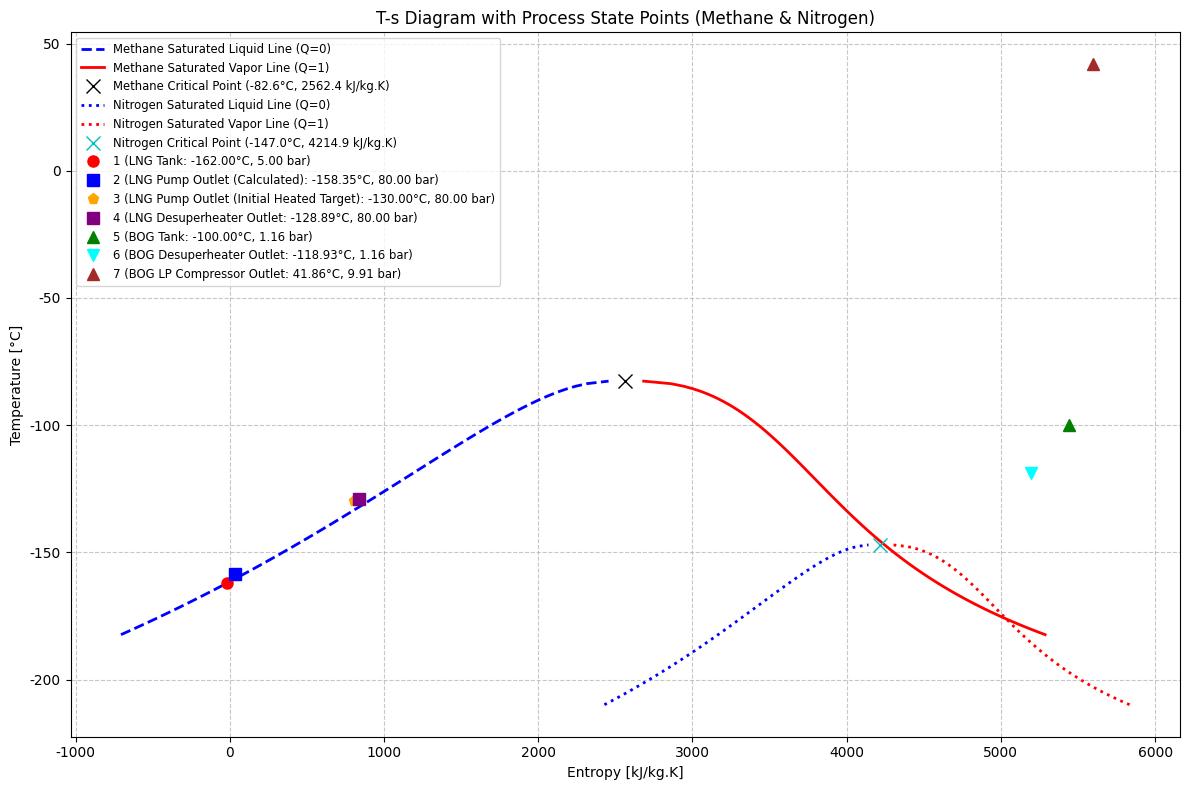

In [179]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# --- Configure matplotlib for default English font support ---
# Ensure unicode minus is handled (use hyphen instead of unicode minus)
plt.rcParams['axes.unicode_minus'] = False
# Remove specific Korean font configuration to avoid errors and use default English fonts
# as requested by the user if Korean fonts cause issues.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']


# --- Methane Critical Point ---
Tc_K_methane = CP.PropsSI('Tcrit', FLUID_LNG)
Pc_Pa_methane = CP.PropsSI('Pcrit', FLUID_LNG)
Tc_C_methane = K_to_C(Tc_K_methane)
Pc_bar_methane = Pa_to_bar(Pc_Pa_methane)

# --- Methane Saturation Curve Data for P-T diagram ---
# Generate temperatures from triple point to critical point
T_triple_K_methane = CP.PropsSI('Ttriple', FLUID_LNG)
T_sat_K_values_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point for sat curve

P_sat_liquid_Pa_values_methane = []
P_sat_vapor_Pa_values_methane = []

for T_K in T_sat_K_values_methane:
    try:
        P_sat_liquid_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturation pressure for liquid (Q=0)
        P_sat_vapor_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturation pressure for vapor (Q=1)
    except ValueError:
        P_sat_liquid_Pa_values_methane.append(np.nan) # Handle cases where P_sat might not be found
        P_sat_vapor_Pa_values_methane.append(np.nan)

P_sat_liquid_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_methane]
P_sat_vapor_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_methane]
T_sat_C_values_methane = [K_to_C(t) for t in T_sat_K_values_methane]

# --- Nitrogen Critical Point ---
FLUID_NITROGEN = 'Nitrogen'
Tc_K_nitrogen = CP.PropsSI('Tcrit', FLUID_NITROGEN)
Pc_Pa_nitrogen = CP.PropsSI('Pcrit', FLUID_NITROGEN)
Tc_C_nitrogen = K_to_C(Tc_K_nitrogen)
Pc_bar_nitrogen = Pa_to_bar(Pc_Pa_nitrogen)

# --- Nitrogen Saturation Curve Data for P-T diagram ---
T_triple_K_nitrogen = CP.PropsSI('Ttriple', FLUID_NITROGEN)
T_sat_K_values_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100)

P_sat_liquid_Pa_values_nitrogen = []
P_sat_vapor_Pa_values_nitrogen = []

for T_K in T_sat_K_values_nitrogen:
    try:
        P_sat_liquid_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        P_sat_vapor_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        P_sat_liquid_Pa_values_nitrogen.append(np.nan)
        P_sat_vapor_Pa_values_nitrogen.append(np.nan)

P_sat_liquid_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_nitrogen]
P_sat_vapor_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_nitrogen]
T_sat_C_values_nitrogen = [K_to_C(t) for t in T_sat_K_values_nitrogen]

# --- Define the state points to plot (aligned with df_streams_full) ---
state_points = [
    # 1. LNG Tank
    {'label': f"1 (LNG Tank: {results['LNG_TANK_T_C']:.2f}°C, {results['LNG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['LNG_TANK_T_C'], 'P_bar': results['LNG_TANK_P_BAR'], 'marker': 'o', 'color': 'red'},
    # 2. LNG Pump Outlet (Calculated)
    {'label': f"2 (LNG Pump Outlet (Calculated): {results['LNG_PUMP_OUT_CALC_T_C']:.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['LNG_PUMP_OUT_CALC_T_C'], 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 's', 'color': 'blue'},
    # 3. LNG Pump Outlet (Initial Heated Target)
    {'label': f"3 (LNG Pump Outlet (Initial Heated Target): {K_to_C(params['T_lng_pump_out_heated']):.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': K_to_C(params['T_lng_pump_out_heated']), 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 'p', 'color': 'orange'},
    # 4. LNG Desuperheater Outlet
    {'label': f"4 (LNG Desuperheater Outlet: {results['LNG_PUMP_OUT_HEATED_T_C']:.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['LNG_PUMP_OUT_HEATED_T_C'], 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 's', 'color': 'purple'},
    # 5. BOG Tank
    {'label': f"5 (BOG Tank: {results['BOG_TANK_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_TANK_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': '^', 'color': 'green'},
    # 6. BOG Desuperheater Outlet
    {'label': f"6 (BOG Desuperheater Outlet: {results['BOG_DESUPERHEATER_OUT_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_DESUPERHEATER_OUT_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': 'v', 'color': 'cyan'},
    # 7. BOG LP Compressor Outlet
    {'label': f"7 (BOG LP Compressor Outlet: {results['BOG_COMP_OUT_T_C']:.2f}°C, {results['BOG_COMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['BOG_COMP_OUT_T_C'], 'P_bar': results['BOG_COMP_OUT_P_BAR'], 'marker': '^', 'color': 'brown'}
]

# --- Plotting the P-T Diagram ---
fig_pt_diag = plt.figure(figsize=(12, 8)) # Assign to a variable for potential saving, larger figure

# Methane Saturation Curves
plt.plot(T_sat_C_values_methane, P_sat_liquid_bar_values_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(T_sat_C_values_methane, P_sat_vapor_bar_values_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')
plt.plot(Tc_C_methane, Pc_bar_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {Pc_bar_methane:.1f} bar)')

# Nitrogen Saturation Curves
plt.plot(T_sat_C_values_nitrogen, P_sat_liquid_bar_values_nitrogen, 'b:', linewidth=2, label='Nitrogen Saturated Liquid Line (Q=0)') # Dotted line for Nitrogen
plt.plot(T_sat_C_values_nitrogen, P_sat_vapor_bar_values_nitrogen, 'r:', linewidth=2, label='Nitrogen Saturated Vapor Line (Q=1)')   # Dotted line for Nitrogen
plt.plot(Tc_C_nitrogen, Pc_bar_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {Pc_bar_nitrogen:.1f} bar)') # Cyan cross for Nitrogen critical point

for point in state_points:
    plt.plot(point['T_C'], point['P_bar'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('P-T Diagram with Process State Points (Methane & Nitrogen)')
plt.xlabel('Temperature [°C]')
plt.ylabel('Pressure [bar]')
plt.yscale('log') # Pressure often spans several orders of magnitude, so log scale is useful
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.xlim(min(min(T_sat_C_values_methane), min(T_sat_C_values_nitrogen)) - 10, max([p['T_C'] for p in state_points]) + 20)
plt.ylim(0.1, max(Pc_bar_methane, Pc_bar_nitrogen, max([p['P_bar'] for p in state_points])) * 1.5)
plt.tight_layout()
plt.show()


# --- Methane Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_methane = []
s_sat_vapor_values_methane = []

for T_K in T_sat_K_values_ts_methane:
    try:
        # For saturated liquid and vapor entropy, we specify T and Q
        s_sat_liquid_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturated liquid entropy (Q=0)
        s_sat_vapor_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturated vapor entropy (Q=1)
    except ValueError:
        s_sat_liquid_values_methane.append(np.nan)
        s_sat_vapor_values_methane.append(np.nan)

T_sat_C_values_ts_methane = [K_to_C(t) for t in T_sat_K_values_ts_methane]

# --- Nitrogen Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_nitrogen = []
s_sat_vapor_values_nitrogen = []

for T_K in T_sat_K_values_ts_nitrogen:
    try:
        s_sat_liquid_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        s_sat_vapor_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        s_sat_liquid_values_nitrogen.append(np.nan)
        s_sat_vapor_values_nitrogen.append(np.nan)

T_sat_C_values_ts_nitrogen = [K_to_C(t) for t in T_sat_K_values_ts_nitrogen]

# --- Calculate entropy for existing state points (assuming Methane properties for these points) ---
state_points_ts = []
for point in state_points:
    T_K_point = C_to_K(point['T_C'])
    P_Pa_point = bar_to_Pa(point['P_bar'])
    try:
        # For process points, assume FLUID_LNG (Methane) properties since the states are primarily LNG/Methane rich
        # If a point is for BOG, its entropy can be calculated with FLUID (Methane-Nitrogen mixture).
        # However, for plotting on pure Methane T-s diagram, we'd use Methane's pure component entropy at that T,P.
        # To keep it simple and consistent with the T-s plot for Methane, we'll calculate entropy based on FLUID_LNG.
        # For BOG points, calculating entropy with FLUID_LNG (pure Methane) is an approximation for visualization on a Methane diagram.
        s_point = s_TP(T_K_point, P_Pa_point, FLUID_LNG)
    except ValueError:
        s_point = np.nan # Handle cases where entropy might not be found
    state_points_ts.append(
        {
            'label': point['label'],
            'T_C': point['T_C'],
            's': s_point,
            'marker': point['marker'],
            'color': point['color'],
        }
    )

# --- Plotting the T-s Diagram ---
fig_ts_diag = plt.figure(figsize=(12, 8))

# Methane Saturation Curves
plt.plot(s_sat_liquid_values_methane, T_sat_C_values_ts_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(s_sat_vapor_values_methane, T_sat_C_values_ts_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')

# Methane Critical Point
s_crit_methane = s_TP(Tc_K_methane, Pc_Pa_methane, FLUID_LNG)
plt.plot(s_crit_methane, Tc_C_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {s_crit_methane:.1f} kJ/kg.K)')

# Nitrogen Saturation Curves
plt.plot(s_sat_liquid_values_nitrogen, T_sat_C_values_ts_nitrogen, 'b:', linewidth=2, label='Nitrogen Saturated Liquid Line (Q=0)')
plt.plot(s_sat_vapor_values_nitrogen, T_sat_C_values_ts_nitrogen, 'r:', linewidth=2, label='Nitrogen Saturated Vapor Line (Q=1)')

# Nitrogen Critical Point
s_crit_nitrogen = s_TP(Tc_K_nitrogen, Pc_Pa_nitrogen, FLUID_NITROGEN)
plt.plot(s_crit_nitrogen, Tc_C_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {s_crit_nitrogen:.1f} kJ/kg.K)')

# Plot Process State Points
for point in state_points_ts:
    if not np.isnan(point['s']):
        plt.plot(point['s'], point['T_C'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('T-s Diagram with Process State Points (Methane & Nitrogen)')
plt.xlabel('Entropy [kJ/kg.K]')
plt.ylabel('Temperature [°C]')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

In [178]:
# @title
import pandas as pd

# 동력 소모량 데이터를 위한 리스트 생성
power_data = []

power_data.append({
    "장비": "LNG 펌프",
    "동력 소모량 [MW]": results["LNG_PUMP_POWER_MW"],
    "효율 / 유용도": params["pump_eta"]
})
power_data.append({
    "장비": "BOG 압축기",
    "동력 소모량 [MW]": results["BOG_COMP_POWER_MW"],
    "효율 / 유용도": params["comp_eta"]
})
power_data.append({
    "장비": "디슈퍼히터",
    "동력 소모량 [MW]": "N/A", # 열교환기는 동력을 소모하지 않으므로 N/A
    "효율 / 유용도": params["desuperheater_effectiveness"]
})

# 총 동력 소모량 추가
power_data.append({
    "장비": "총 시스템 동력",
    "동력 소모량 [MW]": results["TOTAL_POWER_MW"],
    "효율 / 유용도": "N/A" # 총 시스템 동력은 개별 효율을 갖지 않음
})

# 데이터프레임 생성
df_power_summary = pd.DataFrame(power_data)

print("\n=== 장비 동력 소모량 요약 ===")
display(df_power_summary.round(3))


=== 장비 동력 소모량 요약 ===


,장비,동력 소모량 [MW],효율 / 유용도
0,LNG 펌프,1.527778,0.75
1,BOG 압축기,2.201008,0.665
2,디슈퍼히터,N/A,0.7
3,총 시스템 동력,3.728785,N/A


In [74]:
mermaid_diagram_code = """graph TD
    subgraph LNG Stream
        A[LNG 탱크] --> B(LNG 펌프)
        B --> C(LNG 프리히터)
        C --> D{디슈퍼히터 (LNG 냉각 측)}
    end

    subgraph BOG Stream
        E[BOG 탱크] --> F{디슈퍼히터 (BOG 가열 측)}
        F --> G(BOG 저압 압축기)
    end

    D -- 냉각된 LNG --> H[LNG 검토 종료]
    G -- 압축된 BOG --> I[BOG 검토 종료]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style E fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
    style I fill:#f9f,stroke:#333,stroke-width:2px
"""

print("Mermaid diagram code generated.")

Mermaid diagram code generated.


## Simplified LNG Vaporization Process System Diagram

Google Colab's Markdown cells do not directly render Mermaid diagrams as images. To view the visualized diagram, you can paste the code below into an online tool like Mermaid Live Editor (https://mermaid.live/).

```mermaid
graph TD
    subgraph LNG Stream
        A[LNG Tank] --> B(LNG Pump)
        B --> C(LNG Preheater)
        C --> D{Desuperheater (LNG Cooling Side)}
    end

    subgraph BOG Stream
        E[BOG Tank] --> F{Desuperheater (BOG Heating Side)}
        F --> G(BOG LP Compressor)
    end

    D -- Cooled LNG --> H[LNG Process End]
    G -- Compressed BOG --> I[BOG Process End]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style E fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
    style I fill:#f9f,stroke:#333,stroke-width:2px
```